# investalyze — price segments → encoded vectors

A walk-through of the `investalyze.analysis` layer, end to end: **load** a price universe →
**chop** each series into fixed-width windows → **split** every window into a *history* block and the
*future* that follows → **encode** both into comparable vectors with leak-free normalisation.

This is the input the later stages build on — clustering the histories into motifs, then studying how
the futures behave for similar histories (the transition analysis).

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from helpers import connect_readonly

from investalyze.analysis import encodings, segments

con = connect_readonly()

## 1 · Select the universe

Pick broadly by class (`stocks`, `indices`, `bonds`, `currencies`) and/or finely by ticker.
`load_series` returns a long frame `[Ticker, Date, AssetClass, Price]` (stocks use adjusted close,
market data uses close).

In [2]:
CLASSES = ['stocks', 'indices']
TICKERS = ['AAPL', 'MSFT', '^DJI', '^NDX']  # or None for every ticker in the chosen classes

CLASSES = ['indices']
TICKERS = None

series = segments.load_series(con, classes=CLASSES, tickers=TICKERS)
series.groupby(['AssetClass', 'Ticker']).size()

AssetClass  Ticker
indices     ^AEX      11054
            ^AOR      13046
            ^ATH       9779
            ^BEL20     9003
            ^BET       6378
                      ...  
            ^TOP40     7788
            ^TSX      12621
            ^TWSE      7823
            ^UKX      23118
            ^XU100     9110
Length: 62, dtype: int64

## 2 · Chop the series into windows

`build_segments` slides a fixed-width window over each instrument (by row position, ignoring calendar
gaps) and returns raw prices `W` plus `meta`. Each window holds a **history** block of
`HISTORY_LENGTH` rows followed by `FUTURE_LENGTH` rows of **future** — so `WINDOW_LENGTH` is their
sum. `STRIDE` sets the step between window starts.

In [3]:
HISTORY_LENGTH = 20  # rows you observe / cluster on
FUTURE_LENGTH = 5  # rows that follow (the transition layer will study these)
WINDOW_LENGTH = HISTORY_LENGTH + FUTURE_LENGTH
STRIDE = 20  # step between window starts (== HISTORY_LENGTH -> non-overlapping history)

W, meta = segments.build_segments(series, window_length=WINDOW_LENGTH, stride=STRIDE)
print('W       ', W.shape, '(raw prices)')
print('windows ', len(meta))
meta.head()

W        (31687, 25) (raw prices)
windows  31687


,segment_id,Ticker,AssetClass,start_date,end_date,start_idx
0,0,^AEX,indices,1983-01-03,1983-02-04,0
1,1,^AEX,indices,1983-01-31,1983-03-04,20
2,2,^AEX,indices,1983-02-28,1983-04-05,40
3,3,^AEX,indices,1983-03-28,1983-05-03,60
4,4,^AEX,indices,1983-04-27,1983-06-03,80


## 3 · Split each window into history + future

The split is a plain downstream slice at `HISTORY_LENGTH` — the core stays encoding-agnostic and just
hands back raw windows.

In [4]:
history = W[:, :HISTORY_LENGTH]
future = W[:, HISTORY_LENGTH:]
print('history', history.shape, ' future', future.shape)

history (31687, 20)  future (31687, 5)


## 4 · Encode into comparable vectors

Raw windows at different price levels are not comparable, so each one is normalised into a vector.
Every encoding has the same signature — `fn(history, future=None)` — and learns its parameters from
the **history only**, applying them to the **future**. Nothing from the future leaks into the encoded
history (section 6 proves it). Each method answers "what counts as the same shape?" differently:

| method | formula | keeps | pros | cons |
|---|---|---|---|---|
| **raw** | — | level + scale | true prices | windows at different levels never overlap; useless for similarity |
| **rebase to 100** | `v / v[0] * 100` | shape + **amplitude** | level-invariant; Euclidean distance = same shape *and* same size of move; future stays continuous with history | anchored to `v[0]` — a noisy first value tilts the window; does not normalise volatility |
| **demean** | `v - mean` | shape + **amplitude** (price units) | removes level without an arbitrary anchor; symmetric | not comparable across price levels (a $500 vs a $5 instrument live on different scales) |
| **z-score** | `(v - mean) / std` | **shape only** | removes level *and* volatility → pure pattern; a 3% wiggle clusters with a 30% rally of the same form | discards amplitude (can't tell a big move from a small one); unstable for near-flat histories (std → 0) |
| **min-max** | `(v - min) / (max - min)` | shape, bounded [0,1] | bounded range, easy to read | dominated by extremes; a future outside the history's range lands outside [0,1] |

`log_returns(v)` is a different *representation* (per-step returns, length `m-1`): additive and
symmetric up/down, better for statistical/Markov modelling than for overlaying shapes — so it is
exercised in section 6 rather than overlaid below.

**For motif clustering, amplitude usually matters → rebase-to-100 (or demean) + Euclidean.** Use
z-score only when pure shape, ignoring move size, is genuinely what you want to group on.

## 5 · Compare encodings visually

The same sample of windows under each encoding — **history solid, future dashed**, drawn continuously
so you can see how each method aligns the shapes and where the future sits relative to the history.

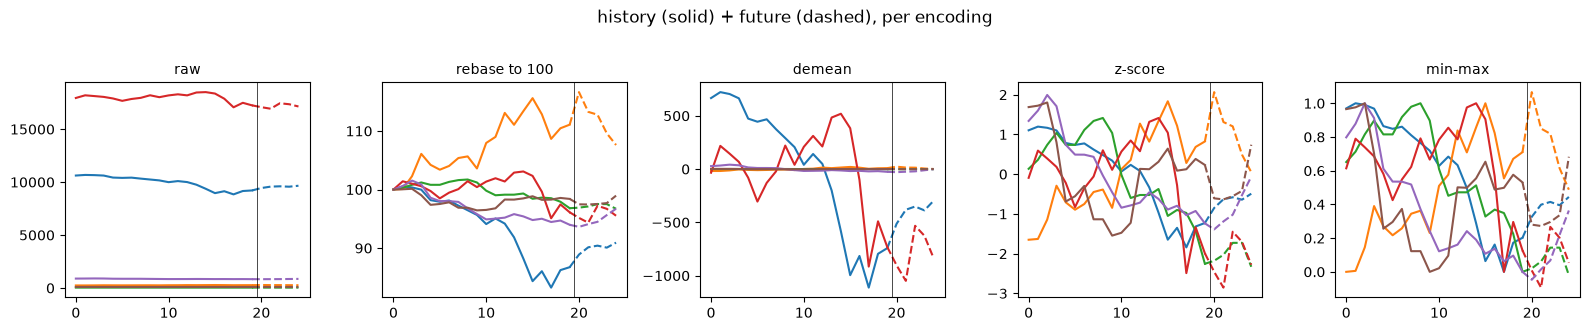

In [5]:
methods = {
    'raw': lambda h, f: (h, f),
    'rebase to 100': encodings.rebase_to_100,
    'demean': encodings.demean,
    'z-score': encodings.zscore,
    'min-max': encodings.minmax,
}

rng = np.random.default_rng(0)
idx = rng.choice(len(W), size=min(6, len(W)), replace=False)
hx = np.arange(HISTORY_LENGTH)
fx = np.arange(HISTORY_LENGTH - 1, WINDOW_LENGTH)  # start at the last history point so the line connects

fig, axes = plt.subplots(1, len(methods), figsize=(3.2 * len(methods), 3.2))
for ax, (name, fn) in zip(axes, methods.items()):
    h_enc, f_enc = fn(history[idx], future[idx])
    for hi, fi in zip(h_enc, f_enc):
        (line,) = ax.plot(hx, hi)
        ax.plot(fx, np.concatenate([hi[-1:], fi]), ls='--', color=line.get_color())  # bridge history->future
    ax.axvline(HISTORY_LENGTH - 0.5, color='k', lw=0.5)
    ax.set_title(name, fontsize=10)
fig.suptitle('history (solid) + future (dashed), per encoding', y=1.02)
plt.tight_layout()
plt.show()

## 6 · No look-ahead leakage

Because every encoding fits its parameters on the history alone, the encoded history is independent of
the future. Wreck the future and re-encode — the history vector is bit-identical for all five.

In [6]:
i = 0
wrecked = np.full_like(future[[i]], 999.0)
for name, fn in [
    ('rebase_to_100', encodings.rebase_to_100),
    ('log_returns', encodings.log_returns),
    ('demean', encodings.demean),
    ('zscore', encodings.zscore),
    ('minmax', encodings.minmax),
]:
    h0, _ = fn(history[[i]], future[[i]])
    h1, _ = fn(history[[i]], wrecked)
    print(f'{name:13s} history unchanged: {np.array_equal(h0, h1)}')

rebase_to_100 history unchanged: True
log_returns   history unchanged: True
demean        history unchanged: True
zscore        history unchanged: True
minmax        history unchanged: True
